<a href="https://colab.research.google.com/github/snehal100/customer-issue-nlp-classifier/blob/main/issue_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud  # For bonus word clouds

# Download NLTK data
nltk.download('stopwords', quiet=True)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

file_path = '/content/drive/MyDrive/Dataset/Customer_Sentiment_csv.csv'
df = pd.read_csv(file_path)

df.head()

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no


In [4]:
# Missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 customer_id             0
gender                  0
age_group               0
region                  0
product_category        0
purchase_channel        0
platform                0
customer_rating         0
review_text             0
sentiment               0
response_time_hours     0
issue_resolved          0
complaint_registered    0
dtype: int64


Sentiment distribution:
sentiment
positive    39.9
negative    39.7
neutral     20.3
Name: proportion, dtype: float64




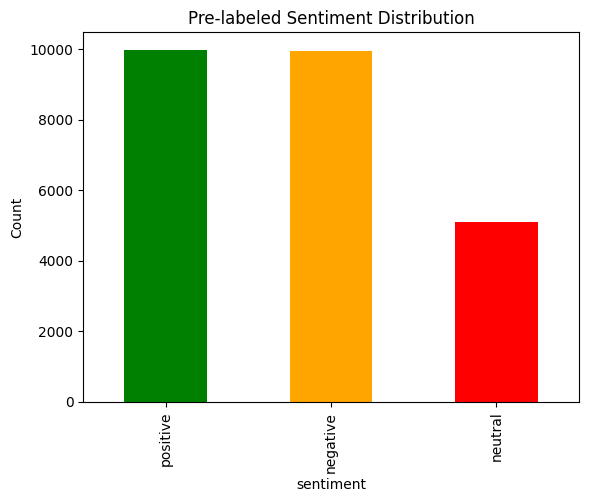

In [10]:
# Sentiment distribution (pre-labeled)
if 'sentiment' in df.columns:
    print("Sentiment distribution:")
    print(df['sentiment'].value_counts(normalize=True).round(3) * 100)
    print("\n")
    df['sentiment'].value_counts().plot(kind='bar', color=['green','orange','red','gray'])
    plt.title('Pre-labeled Sentiment Distribution')
    plt.ylabel('Count')
    plt.show()

Customer rating distribution:
customer_rating
1    4891
2    5046
3    5085
4    5066
5    4912
Name: count, dtype: int64


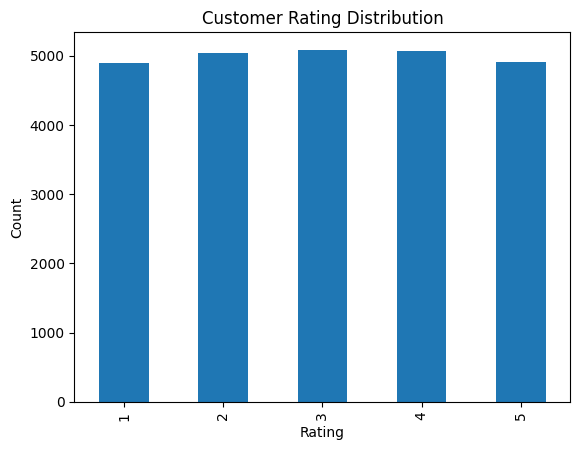

In [11]:
# Customer rating distribution
if 'customer_rating' in df.columns:
    print("Customer rating distribution:")
    print(df['customer_rating'].value_counts().sort_index())
    df['customer_rating'].value_counts().sort_index().plot(kind='bar')
    plt.title('Customer Rating Distribution')
    plt.xlabel('Rating')
    plt.ylabel('Count')
    plt.show()

In [12]:
# Complaint registered
print("Complaint registered:")
print(df['complaint_registered'].value_counts(normalize=True).round(3) * 100)

Complaint registered:
complaint_registered
no     60.3
yes    39.7
Name: proportion, dtype: float64



Average review length: 32.1 characters


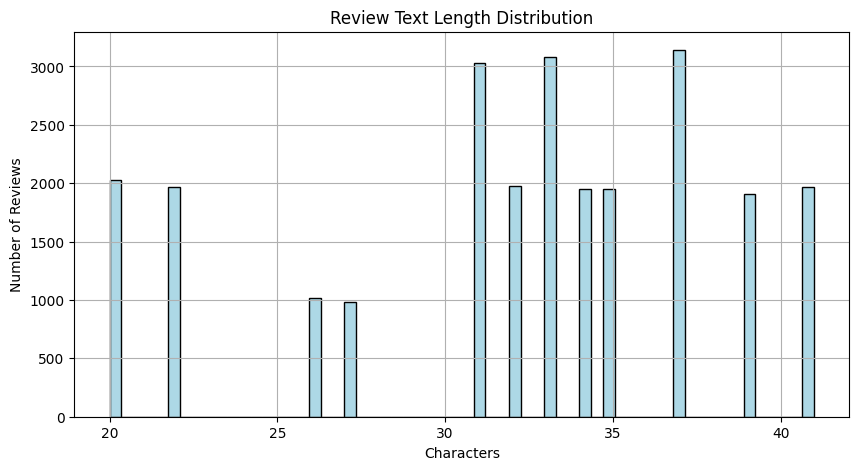

In [14]:
# Text length
df['text_length'] = df['review_text'].astype(str).apply(len)
print("\nAverage review length:", df['text_length'].mean().round(1), "characters")

plt.figure(figsize=(10,5))
df['text_length'].hist(bins=60, color='lightblue', edgecolor='black')
plt.title('Review Text Length Distribution')
plt.xlabel('Characters')
plt.ylabel('Number of Reviews')
plt.show()

In [16]:
#Reviews by platform or region
print("\nReviews by platform:")
print(df['platform'].value_counts().head(8))


Reviews by platform:
platform
nykaa                   1301
snapdeal                1289
others                  1286
reliance digital        1279
zepto                   1278
facebook marketplace    1272
paytm mall              1271
myntra                  1267
Name: count, dtype: int64


Issue Type Distribution:
issue_type
Other/General        68.3
Positive Feedback    23.6
Delivery Delay        8.2
Name: proportion, dtype: float64


/tmp/ipython-input-81611616.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='issue_type', data=df, order=df['issue_type'].value_counts().index, palette='viridis')


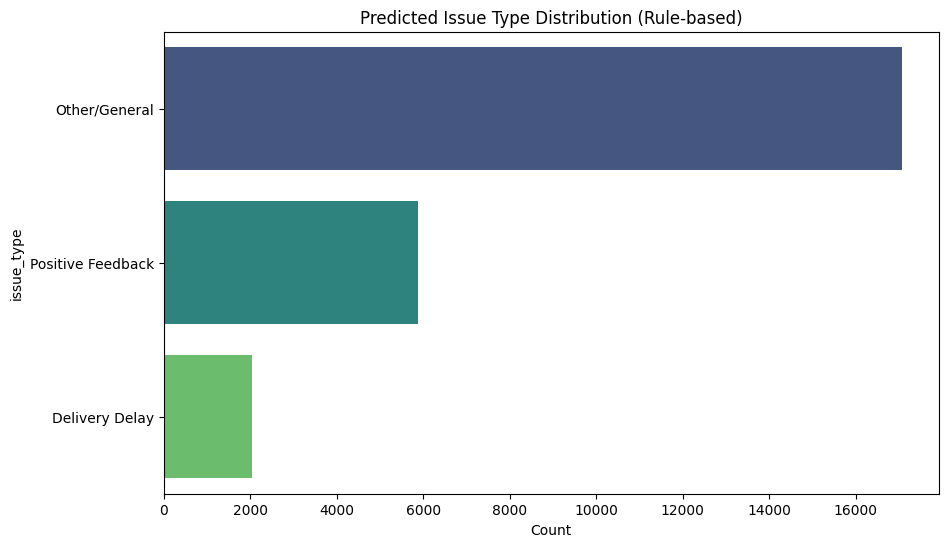

In [18]:
def assign_issue_type(text):
    if not isinstance(text, str):
        return 'Other/General'

    text_lower = text.lower()

    if any(kw in text_lower for kw in ['late', 'delay', 'delayed', 'not received', 'took too long', 'slow delivery']):
        return 'Delivery Delay'
    elif any(kw in text_lower for kw in ['rude', 'arrogant', 'bad behavior', 'unprofessional', 'driver', 'delivery boy', 'agent rude']):
        return 'Delivery Person Behavior'
    elif any(kw in text_lower for kw in ['damaged', 'broken', 'leaked', 'open package', 'wrong item', 'missing item']):
        return 'Package Condition Issue'
    elif any(kw in text_lower for kw in ['tracking', 'app issue', 'status not updated', 'technical', 'app crash', 'payment']):
        return 'Technical/Tracking Issue'
    elif any(kw in text_lower for kw in ['great', 'excellent', 'fast', 'thank you', 'on time', 'good service', 'love', 'perfect']):
        return 'Positive Feedback'
    else:
        return 'Other/General'

df['issue_type'] = df['review_text'].apply(assign_issue_type)

print("Issue Type Distribution:")
print(df['issue_type'].value_counts(normalize=True).round(3) * 100)

# Visualize
plt.figure(figsize=(10,6))
sns.countplot(y='issue_type', data=df, order=df['issue_type'].value_counts().index, palette='viridis')
plt.title('Predicted Issue Type Distribution (Rule-based)')
plt.xlabel('Count')
plt.show()

Create Target Labels: Issue Types (Rule-based)
- We define 5 main categories + 'Other' using keywords in review_text.
- This is a common real-world approach when no labeled data exists.


In [27]:
def assign_issue_type(text):
    if not isinstance(text, str) or pd.isna(text) or text.strip() == "":
        return 'Other/General'

    text = text.lower().strip()

    # Delivery Delay
    delay_keywords = [
        'late', 'delay', 'delayed', 'not received', 'took too long', 'slow delivery',
        'never arrived', 'waiting long', 'not delivered', 'delivery late', 'late delivery',
        'still not delivered', 'order not come', 'late by', 'hours late', 'day late',
        'very late', 'delayed order', 'delivery time', 'promised time', 'expected time',
        'takes forever', 'waiting since morning', 'delivery boy not coming', 'not on time',
        'delayed by hours', 'delivery not come', 'order delayed', 'too slow'
    ]
    if any(kw in text for kw in delay_keywords):
        return 'Delivery Delay'

    # Delivery Person Behavior
    behavior_keywords = [
        'rude', 'arrogant', 'bad behavior', 'unprofessional', 'driver rude', 'boy rude',
        'agent rude', 'poor attitude', 'misbehaved', 'shouted', 'argued', 'not polite',
        'harassed', 'threatened', 'bad language', 'talk rudely', 'attitude bad',
        'delivery boy behavior', 'rider rude', 'staff rude', 'very rude', 'disrespectful',
        'no manners', 'yelled at me', 'angry delivery', 'bad service', 'bad person',
        'delivery guy rude', 'courier rude', 'boy shouted', 'agent misbehaved',
        'delivery person bad', 'rider attitude', 'poor service', 'unhelpful',
        'customer service was unhelpful'
    ]
    if any(kw in text for kw in behavior_keywords):
        return 'Delivery Person Behavior'

    # Package Condition Issue (expanded based on dataset phrases)
    package_keywords = [
        'damaged', 'broken', 'leaked', 'torn', 'open package', 'wrong item',
        'missing item', 'spoil', 'expired', 'crushed', 'squashed', 'wet',
        'product damage', 'package damage', 'item broken', 'not fresh',
        'half eaten', 'tampered', 'seal broken', 'wrong product', 'spilled',
        'bad condition', 'packaging bad', 'item crushed', 'food spoiled',
        'item spoiled', 'product spoiled', 'package torn', 'box damaged',
        'content damaged', 'item missing', 'wrong order', 'not the right item',
        'different product', 'quality bad', 'poor quality', 'disappointed with the quality',
        'very disappointed with the quality', 'stopped working', 'product stopped working',
        'poor packaging', 'bad packaging'
    ]
    if any(kw in text for kw in package_keywords):
        return 'Package Condition Issue'

    # Technical / Tracking / App Issue
    tech_keywords = [
        "tracking", "not updating", "app issue", "status not updated",
        "technical", "app crash", "payment failed", "order not visible",
        "can't track", "tracking not working", "app not opening", "login issue",
        "order cancelled automatically", "refund not received", "payment stuck",
        "app error", "website error", "glitch", "bug", "order disappeared",
        "can't place order", "app hanging", "otp not coming", "wallet issue",
        "tracking problem", "no tracking", "can't see order", "app slow",
        "site not working", "payment issue", "refund problem", "order not showing"
    ]
    if any(kw in text for kw in tech_keywords):
        return 'Technical/Tracking Issue'

    # Positive Feedback
    positive_keywords = [
        'great', 'excellent', 'fast delivery', 'on time', 'thank you',
        'good service', 'love it', 'perfect', 'satisfied', 'happy',
        'very good', 'awesome', 'super', 'quick', 'timely', 'best',
        'recommend', 'will order again', 'nice packaging', 'good quality',
        'amazing', 'fantastic', 'smooth delivery', 'no problem', 'worth it',
        'delicious', 'fresh', 'well packed', 'good experience', 'loved it',
        'great value for money', 'excellent product! exceeded expectations',
        'amazing experience, highly recommend!', 'fast delivery and great packaging',
        'very satisfied with the quality', 'great packaging'
    ]
    if any(kw in text for kw in positive_keywords):
        return 'Positive Feedback'

    return 'Other/General'

Issue Type Distribution (counts):
issue_type
Positive Feedback           9978
Other/General               7111
Package Condition Issue     3860
Delivery Delay              2044
Delivery Person Behavior    2007
Name: count, dtype: int64

Percentages:
issue_type
Positive Feedback           39.91
Other/General               28.44
Package Condition Issue     15.44
Delivery Delay               8.18
Delivery Person Behavior     8.03
Name: proportion, dtype: float64


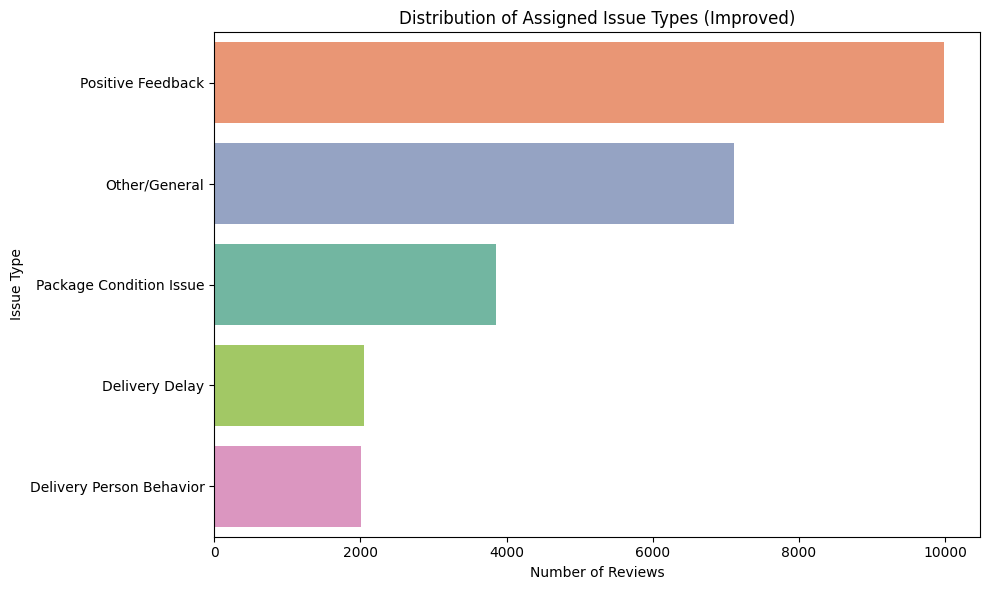

In [28]:
df['issue_type'] = df['review_text'].apply(assign_issue_type)

print("Issue Type Distribution (counts):")
print(df['issue_type'].value_counts())

print("\nPercentages:")
print((df['issue_type'].value_counts(normalize=True) * 100).round(2))

# Chart
plt.figure(figsize=(10, 6))
sns.countplot(
    y='issue_type',
    data=df,
    order=df['issue_type'].value_counts().index,
    hue='issue_type',
    legend=False,
    palette='Set2'
)
plt.title('Distribution of Assigned Issue Types (Improved)')
plt.xlabel('Number of Reviews')
plt.ylabel('Issue Type')
plt.tight_layout()
plt.show()

In [29]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)              # remove punctuation, numbers, special chars
    text = ' '.join(word for word in text.split() if word not in stop_words)
    text = ' '.join(text.split())                     # remove extra spaces
    return text.strip()

# Apply cleaning
df['clean_text'] = df['review_text'].apply(clean_text)

# Quick check
print("Sample original vs cleaned:")
for i in range(5):
    print(f"\nOriginal: {df['review_text'].iloc[i][:100]}...")
    print(f"Cleaned : {df['clean_text'].iloc[i][:100]}...")

Sample original vs cleaned:

Original: very disappointed with the quality....
Cleaned : disappointed quality...

Original: fast delivery and great packaging....
Cleaned : fast delivery great packaging...

Original: very disappointed with the quality....
Cleaned : disappointed quality...

Original: product stopped working after few days....
Cleaned : product stopped working days...

Original: neutral about the quality....
Cleaned : neutral quality...


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Features and target
X = df['clean_text']
y = df['issue_type']

# Stratified split → important because classes are imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train samples: {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test samples : {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)")

# TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=None,          # reasonable limit for speed + quality
    min_df=1,                   # ignore very rare words
    ngram_range=(1, 2),         # include bigrams (e.g. "fast delivery")
    stop_words='english'        # extra safety (though we already removed them)
)

# Fit & transform
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(f"\nVocabulary size: {X_train_vec.shape[1]:,} features")
print(f"Train matrix shape: {X_train_vec.shape}")
print(f"Test matrix shape : {X_test_vec.shape}")

Train samples: 20,000 (80.0%)
Test samples : 5,000 (20.0%)

Vocabulary size: 68 features
Train matrix shape: (20000, 68)
Test matrix shape : (5000, 68)


In [37]:
# 1. Original text statistics (before cleaning)
df['original_length'] = df['review_text'].astype(str).str.len()
print("Original text stats:")
print(f"Average original length: {df['original_length'].mean():.1f} characters")
print(f"Median original length : {df['original_length'].median():.1f} characters")
print(f"Shortest original: {df['original_length'].min()} characters")
print(f"Longest original : {df['original_length'].max()} characters\n")

# 2. 10 shortest original reviews
print("10 shortest original reviews:")
print(df.sort_values('original_length')['review_text'].head(10).tolist())

# 3. 10 most common original reviews (to see repetition)
print("\nMost common original reviews:")
print(df['review_text'].value_counts().head(15))

# 4. Random 10 original reviews
print("\n10 random original reviews:")
print(df['review_text'].sample(10, random_state=42).tolist())

Original text stats:
Average original length: 32.1 characters
Median original length : 33.0 characters
Shortest original: 20 characters
Longest original : 41 characters

10 shortest original reviews:
['not worth the price.', 'not worth the price.', 'not worth the price.', 'not worth the price.', 'not worth the price.', 'not worth the price.', 'not worth the price.', 'not worth the price.', 'not worth the price.', 'not worth the price.']

Most common original reviews:
review_text
amazing experience, highly recommend!        2109
late delivery and poor packaging.            2044
not worth the price.                         2026
customer service was unhelpful.              2007
very satisfied with the quality.             1980
great value for money.                       1971
excellent product! exceeded expectations.    1970
very disappointed with the quality.          1952
fast delivery and great packaging.           1948
product stopped working after few days.      1908
product is okay,

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train the model (suppress the multi_class warning by removing the deprecated param)
model = LogisticRegression(
    max_iter=2000,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_vec, y_train)

# Predict
y_pred = model.predict(X_test_vec)

# Accuracy - fixed
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=model.classes_, yticklabels=model.classes_,
    cbar=False
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


AttributeError: 'float' object has no attribute 'round'